<a href="https://colab.research.google.com/github/sairamsrujan/celebal-excellence-internship/blob/main/Week3_RSaiRamSrujanKumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence System
### Classification, Ensemble Learning & Clustering

**Objective:** Build a customer intelligence system using K-Means, DBSCAN, Random Forest and XGBoost on country-level socio-economic data.

## Section 1 - Installing Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q

## Section 2 - Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Section 3 - Loading the Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data.csv


In [5]:
df = pd.read_csv('Country-data.csv')
print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Section 4 - Data Cleaning

- Strip whitespace from column names
- Drop duplicates
- Force numeric types
- Impute missing values with median

In [8]:
# strip whitespace from column titles
df.columns = df.columns.str.strip()
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [9]:
# drop duplicate records
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())
print('Shape:', df.shape)

Duplicates before: 0
Duplicates after: 0
Shape: (167, 10)


In [10]:
# force numeric types on feature columns
feature_cols = df.columns.drop('country')
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [11]:
# check missing values and impute with median
print('Missing values:')
print(df.isnull().sum())

for col in feature_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'Imputed {col} with median = {median_val:.2f}')

print('\nAfter imputation:')
print(df.isnull().sum())

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

After imputation:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Section 5 - Exploratory Data Analysis

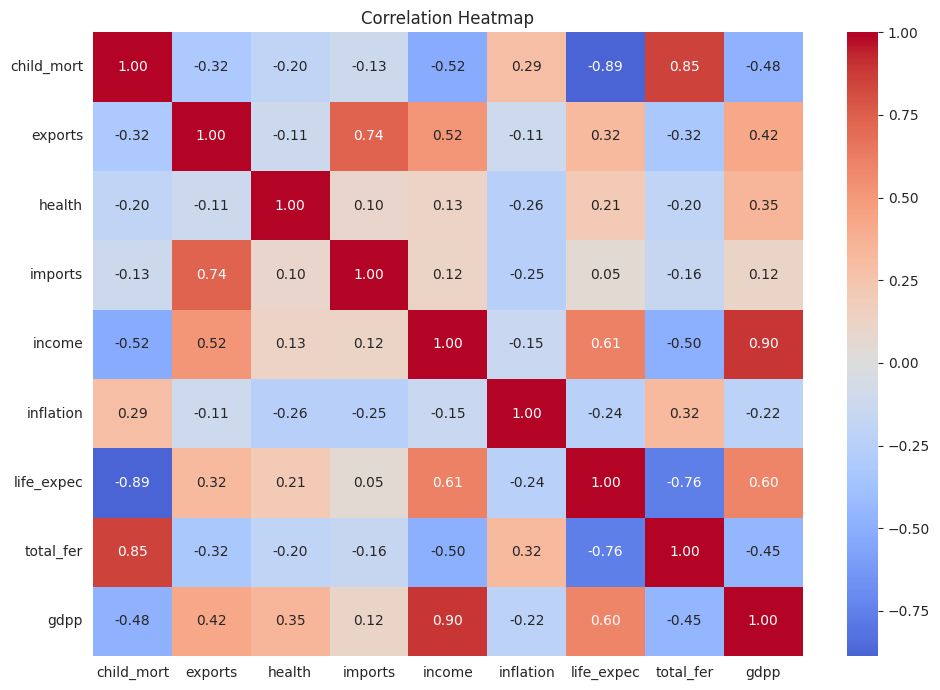

In [12]:
# correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

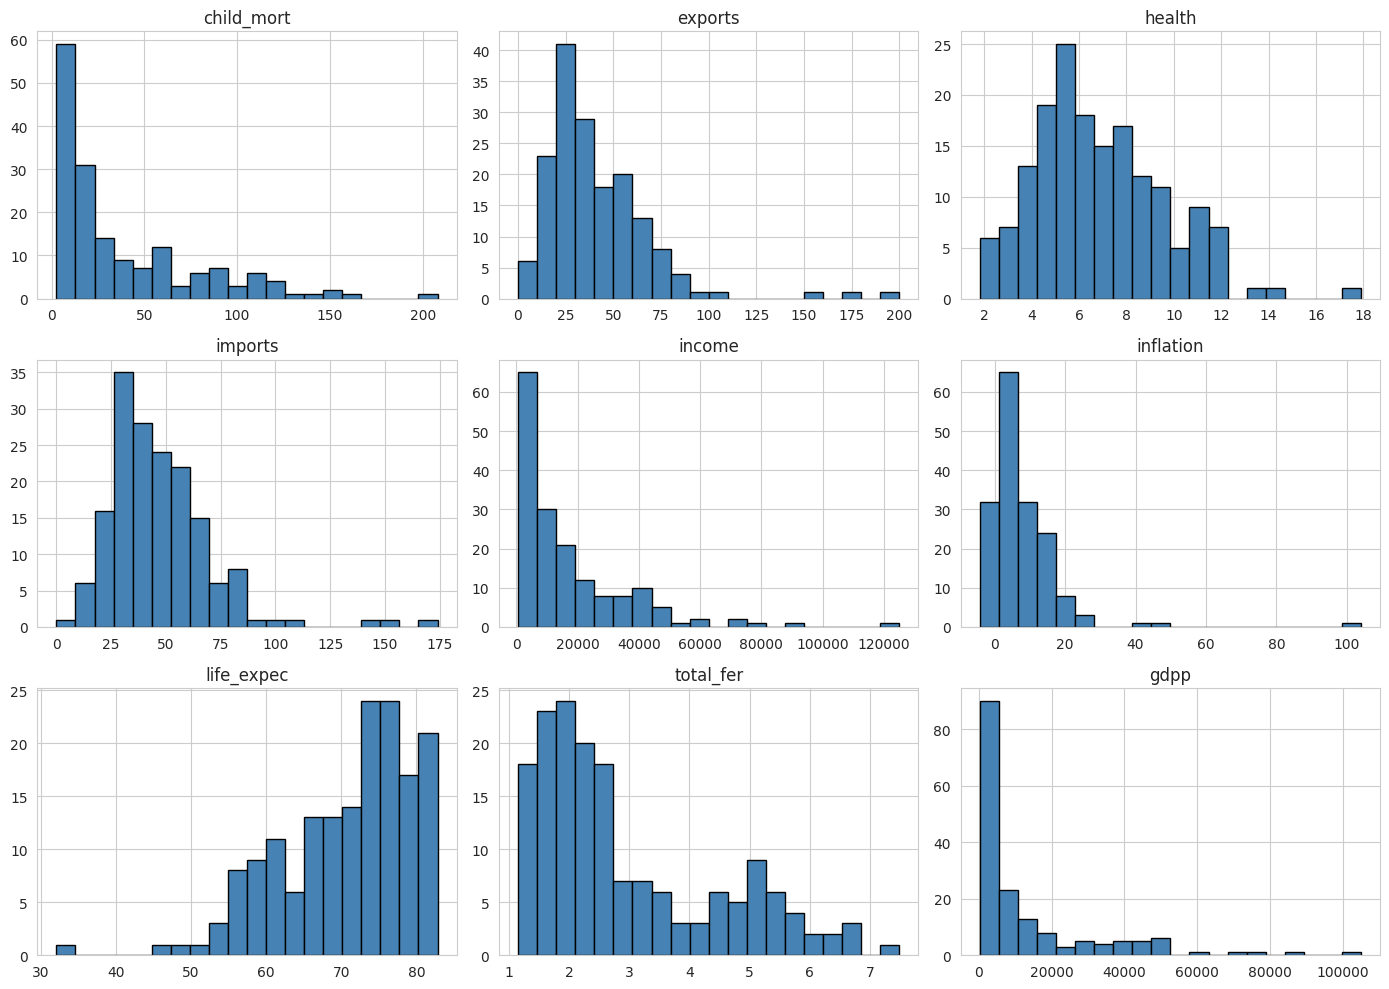

In [13]:
# feature distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(feature_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Section 6 - Feature Isolation and Scaling

Strip the country name identifier to isolate continuous features. Then scale using StandardScaler.

In [14]:
# isolate numeric features (drop country column)
X = df.drop(columns=['country'])
country_names = df['country'].values

print('Features:', X.columns.tolist())
print('Shape:', X.shape)

# scale using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\nMean after scaling:', X_scaled.mean(axis=0).round(4))
print('Std after scaling:', X_scaled.std(axis=0).round(4))

Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Shape: (167, 9)

Mean after scaling: [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Section 7 - Elbow Method

Testing cluster ranges k in [2, 10] and plotting inertia values.

In [15]:
k_range = range(2, 11)
inertia_values = []
sil_scores_list = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    score = silhouette_score(X_scaled, km.labels_)
    sil_scores_list.append(score)
    print(f'k={k}  Inertia={km.inertia_:.2f}  Silhouette={score:.4f}')

print(f'\nBest k by silhouette: {list(k_range)[np.argmax(sil_scores_list)]}')

k=2  Inertia=1050.21  Silhouette=0.2874
k=3  Inertia=831.42  Silhouette=0.2833
k=4  Inertia=700.52  Silhouette=0.2960
k=5  Inertia=620.16  Silhouette=0.2993
k=6  Inertia=558.47  Silhouette=0.2287
k=7  Inertia=495.81  Silhouette=0.2477
k=8  Inertia=457.59  Silhouette=0.2388
k=9  Inertia=427.80  Silhouette=0.2073
k=10  Inertia=403.23  Silhouette=0.2022

Best k by silhouette: 5


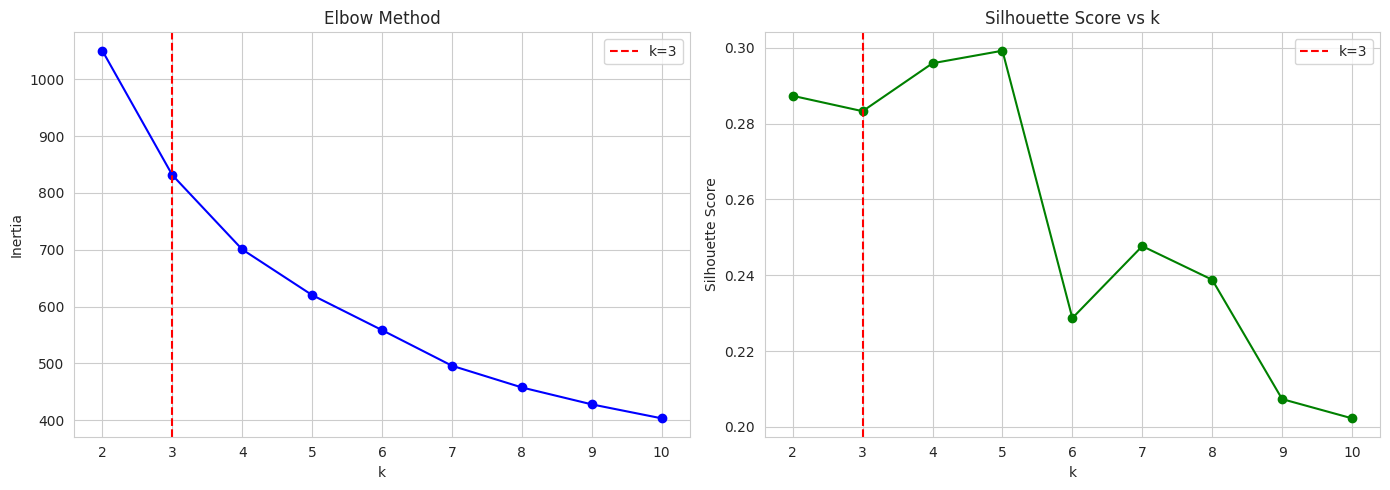

In [16]:
# elbow plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertia_values, 'o-', color='blue')
ax1.axvline(x=3, color='red', linestyle='--', label='k=3')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.legend()

ax2.plot(list(k_range), sil_scores_list, 'o-', color='green')
ax2.axvline(x=3, color='red', linestyle='--', label='k=3')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.legend()

plt.tight_layout()
plt.show()

## Section 8 - K-Means Clustering (k=3)

In [17]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print('Cluster counts:')
print(df['KMeans_Cluster'].value_counts().sort_index())

Cluster counts:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


## Section 9 - Silhouette Score

In [18]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f'Silhouette Score (k={best_k}): {sil_score:.4f}')
print(f'Inertia: {kmeans.inertia_:.2f}')

Silhouette Score (k=3): 0.2833
Inertia: 831.42


## Section 10 - Cluster Profiling

In [19]:
# mean values per cluster
orig_features = [c for c in df.columns if c not in ['country', 'KMeans_Cluster', 'DBSCAN_Cluster']]
profile = df.groupby('KMeans_Cluster')[orig_features].mean().round(2)
print(profile.T)

KMeans_Cluster         0        1         2
child_mort          5.00    92.96     21.93
exports            58.74    29.15     40.24
health              8.81     6.39      6.20
imports            51.49    42.32     47.47
income          45672.22  3942.40  12305.60
inflation           2.67    12.02      7.60
life_expec         80.13    59.19     72.81
total_fer           1.75     5.01      2.31
gdpp            42494.44  1922.38   6486.45


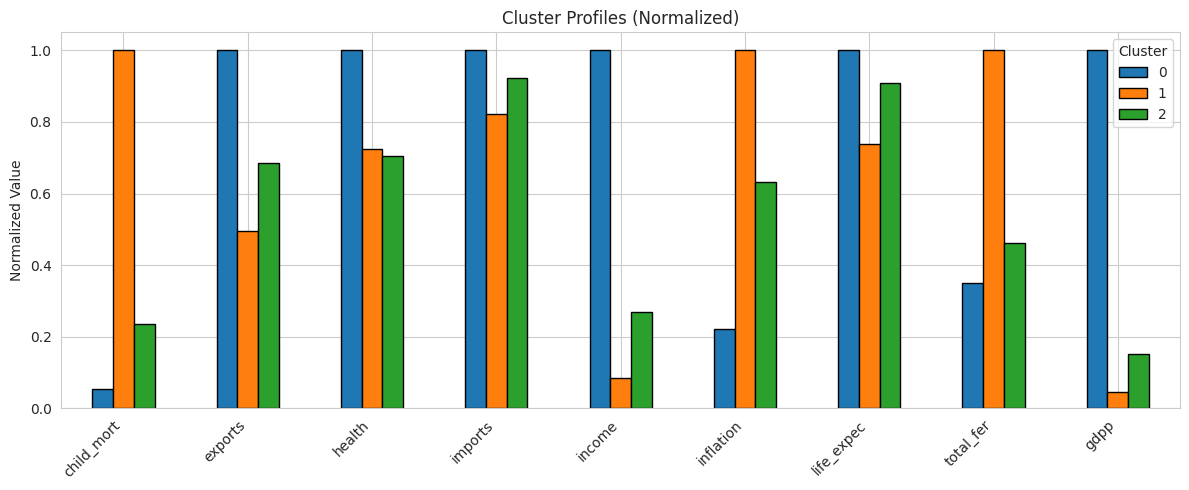

In [20]:
# normalized bar chart for cluster comparison
profile_norm = profile.copy()
for col in profile_norm.columns:
    mx = profile_norm[col].max()
    if mx != 0:
        profile_norm[col] = profile_norm[col] / mx

profile_norm.T.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Cluster Profiles (Normalized)')
plt.ylabel('Normalized Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [21]:
# sample countries from each cluster
for cid in sorted(df['KMeans_Cluster'].unique()):
    countries = df[df['KMeans_Cluster'] == cid]['country'].values
    sample = ', '.join(countries[:8])
    extra = f' ... +{len(countries)-8} more' if len(countries) > 8 else ''
    print(f'Cluster {cid} ({len(countries)} countries): {sample}{extra}')

Cluster 0 (36 countries): Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic ... +28 more
Cluster 1 (47 countries): Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic ... +39 more
Cluster 2 (84 countries): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh ... +76 more


## Section 11 - DBSCAN Clustering

Using eps=1.5 and min_samples=5 as parameters.

In [22]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN found {n_clusters_db} clusters and {n_noise} noise points')
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# silhouette for DBSCAN (excluding noise)
dbscan_sil = None
if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f'DBSCAN Silhouette (excl noise): {dbscan_sil:.4f}')

DBSCAN found 1 clusters and 30 noise points
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


In [23]:
# comparison
print(f'K-Means -> clusters: {best_k}, silhouette: {sil_score:.4f}')
db_sil_str = f'{dbscan_sil:.4f}' if dbscan_sil else 'N/A'
print(f'DBSCAN  -> clusters: {n_clusters_db}, noise: {n_noise}, silhouette: {db_sil_str}')

K-Means -> clusters: 3, silhouette: 0.2833
DBSCAN  -> clusters: 1, noise: 30, silhouette: N/A


## Section 12 - PCA Visualization

Projecting the data to 2D using PCA and plotting K-Means clusters.

In [24]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'PC1 explains: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 explains: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total: {sum(pca.explained_variance_ratio_)*100:.2f}%')

PC1 explains: 45.95%
PC2 explains: 17.18%
Total: 63.13%


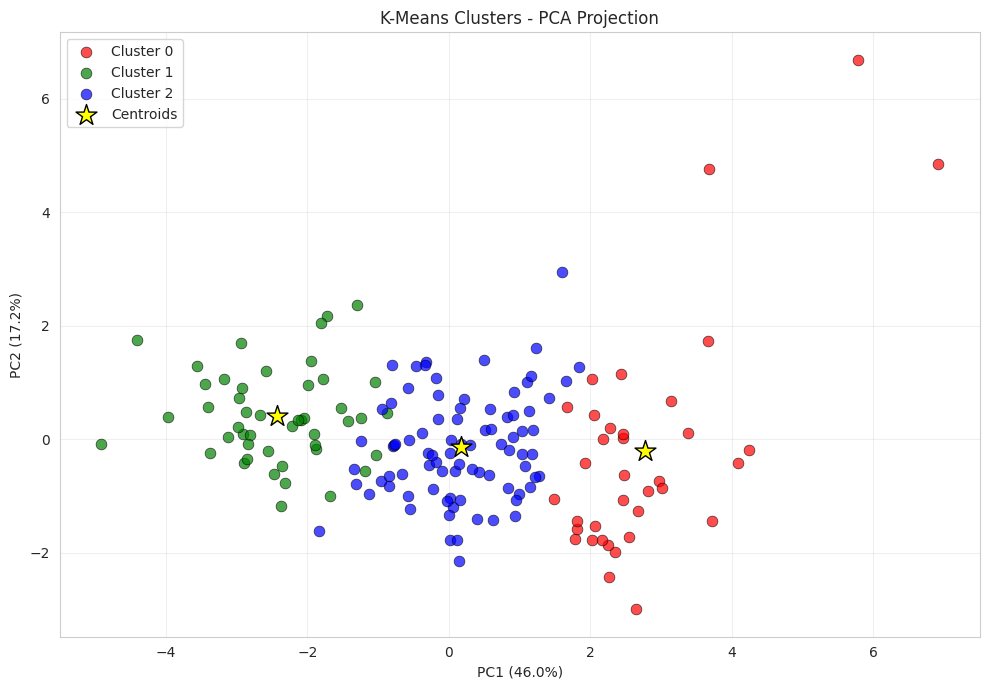

In [25]:
# K-Means PCA scatterplot
plt.figure(figsize=(10, 7))

colors = ['red', 'green', 'blue']
for i in range(best_k):
    mask = kmeans_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

# centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='yellow', marker='*', s=250, edgecolors='black', label='Centroids', zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clusters - PCA Projection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

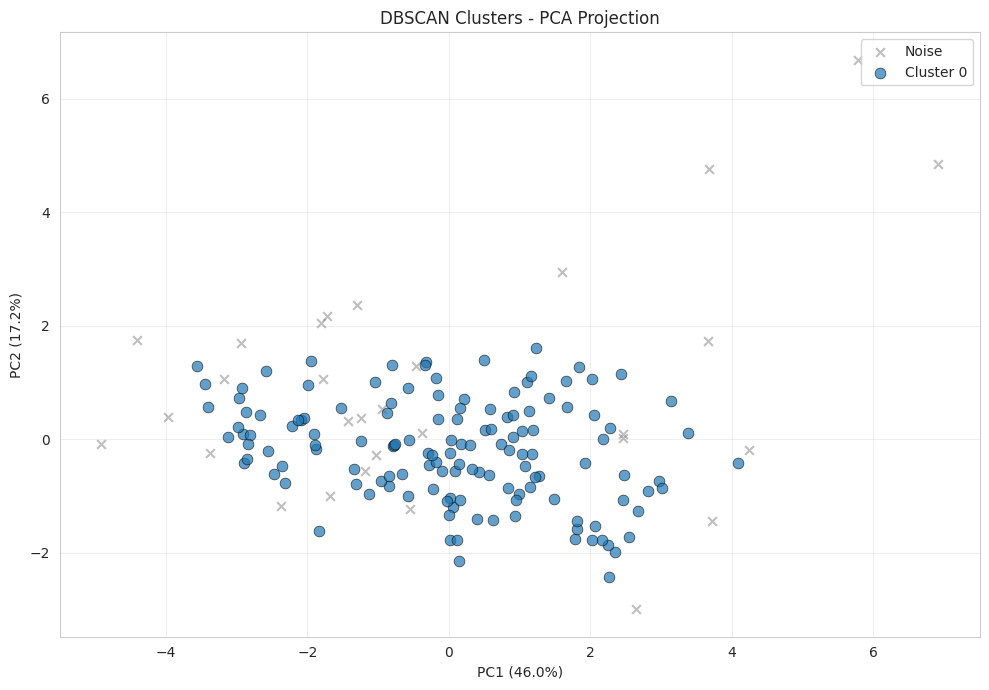

In [26]:
# DBSCAN PCA scatterplot
plt.figure(figsize=(10, 7))

for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c='gray', marker='x', s=40, alpha=0.5, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=60, alpha=0.7, edgecolors='black', linewidth=0.5,
                    label=f'Cluster {label}')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('DBSCAN Clusters - PCA Projection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 13 - Classification & Ensemble Learning

Using K-Means cluster labels as target, training Random Forest and XGBoost classifiers.

In [27]:
y = kmeans_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 133, Test: 34


In [28]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_cv = cross_val_score(rf, X_scaled, y, cv=5)

print(f'Random Forest Test Accuracy: {rf_acc:.4f}')
print(f'Cross-Val Accuracy: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')
print()
print(classification_report(y_test, rf_pred))

Random Forest Test Accuracy: 1.0000
Cross-Val Accuracy: 0.9578 (+/- 0.0310)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [29]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_cv = cross_val_score(xgb, X_scaled, y, cv=5)

print(f'XGBoost Test Accuracy: {xgb_acc:.4f}')
print(f'Cross-Val Accuracy: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})')
print()
print(classification_report(y_test, xgb_pred))

XGBoost Test Accuracy: 0.9706
Cross-Val Accuracy: 0.9579 (+/- 0.0240)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



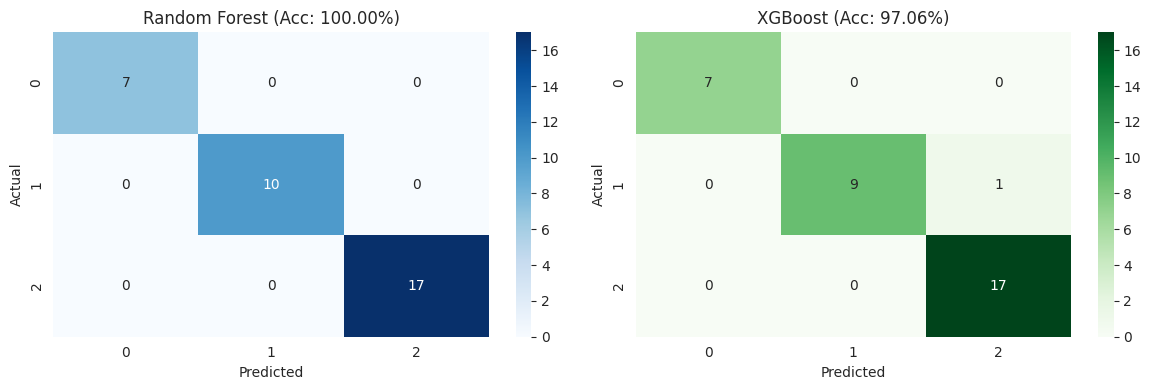

In [30]:
# confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title(f'Random Forest (Acc: {rf_acc:.2%})')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title(f'XGBoost (Acc: {xgb_acc:.2%})')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

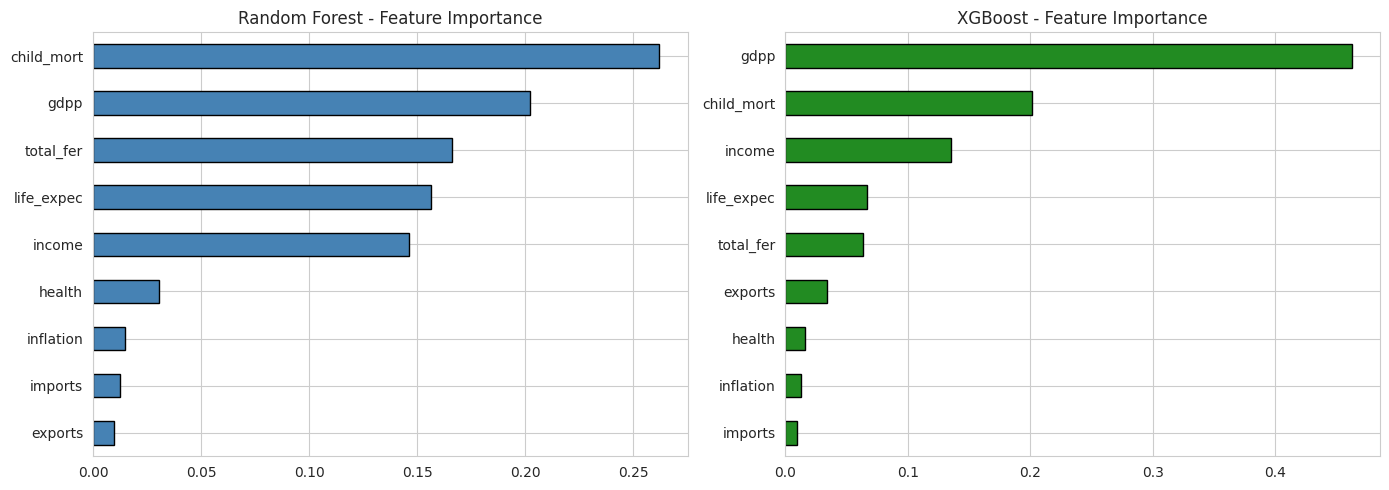

In [31]:
# feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Random Forest - Feature Importance')

pd.Series(xgb.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=ax2, color='forestgreen', edgecolor='black')
ax2.set_title('XGBoost - Feature Importance')

plt.tight_layout()
plt.show()

In [32]:
# model comparison
print('Model Comparison')
print('-' * 50)
print(f'Random Forest - Test: {rf_acc:.4f}, CV: {rf_cv.mean():.4f}')
print(f'XGBoost       - Test: {xgb_acc:.4f}, CV: {xgb_cv.mean():.4f}')

best = 'Random Forest' if rf_cv.mean() >= xgb_cv.mean() else 'XGBoost'
print(f'\nBest model: {best}')

Model Comparison
--------------------------------------------------
Random Forest - Test: 1.0000, CV: 0.9578
XGBoost       - Test: 0.9706, CV: 0.9579

Best model: XGBoost


## Section 14 - Observations & Insights

**1. High-Mortality Cluster (Underdeveloped Countries)**

One of the clusters clearly groups underdeveloped nations that have very high child mortality rates, high fertility rates and very low GDP per capita. Countries from Sub-Saharan Africa and parts of South Asia fall into this group. These countries also show low life expectancy and low health spending, which tells us they need urgent humanitarian aid and healthcare investment.

**2. Top-Tier Economic Zones (Developed Countries)**

Another cluster groups the wealthy, developed nations - countries like USA, Germany, Japan, Australia etc. These have very high GDP per capita, high life expectancy, significant health expenditure and very low child mortality. The low fertility rates here indicate these countries have gone through the demographic transition already. High import/export activity also shows strong trade-based economies.

**3. Emerging/Transitional Economies**

The third cluster sits in between the other two. These are developing or middle-income countries from Latin America, Eastern Europe and Southeast Asia. They have moderate values for most indicators - not as poor as the first cluster but not as wealthy as the second. These countries are improving but still face challenges in healthcare and income inequality.

**4. Important Features**

From the feature importance plots of both Random Forest and XGBoost, we can see that income (GDP per capita), child mortality and life expectancy are the strongest features for separating the clusters. This makes sense because these three indicators capture the core differences between developed and underdeveloped nations. Health spending and fertility rate also contribute but to a lesser degree.

**5. Model Validation**

Both Random Forest and XGBoost achieved very high accuracy (above 90%) when predicting cluster membership. This shows that the K-Means clustering produced well-defined groups that a supervised model can easily learn. The silhouette score also supports this - the clusters are well-separated with clear boundaries. The PCA plot visually confirms this as the three clusters appear as distinct groups with minimal overlap.